In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# the following dataset emulates the joint information from a companies HR file and medical exam
# our goal is to try to approximate salaries from this information
# we have chosen to use a KNN regression
salary = pd.read_csv('salaries.csv')
salary.head()

,Salary,Experience,Gender,Height,Weight,Flexibility,Strenght,BMI,BirthC,Daltonic,Estrogen
0,32064.17357,Senior,Female,160.189080,60.110733,230.467496,227.262099,16.748028,1,NaN,74.619024
1,17160.86833,Junior,Female,153.100363,61.932449,260.080909,244.758004,17.101780,1,NaN,74.581776
2,30940.22480,Senior,Female,166.949128,58.109921,237.047355,236.998125,17.085108,1,NaN,85.510909
3,21036.86527,Junior,Male,173.952647,75.975594,151.578682,287.952815,21.061525,0,Dychromassy,22.091243
4,18855.00061,Junior,Male,180.282763,75.418624,152.502660,283.185533,21.134343,0,Dychromassy,21.749843


In [3]:
salary.shape

(200, 11)

# Formal transformations

In [4]:
salary['Daltonic'].value_counts(dropna=False)

Daltonic
NaN              99
Dychromassy      53
Monochromassy    48
Name: count, dtype: int64

In [5]:
salary['Daltonic'] = salary['Daltonic'].fillna('none')
salary['Daltonic'].head()

0           none
1           none
2           none
3    Dychromassy
4    Dychromassy
Name: Daltonic, dtype: object

In [6]:
# one hot encoding
# you can also use sklearn.preprocessing.OneHotEncoder
#since we only accept numeric values, we have to turn the categorical variables into numerics


pd.get_dummies(salary['Daltonic']).head()
#pd.get_dummies(salary['Daltonic']).astype(int).head()
#pd.get_dummies(salary['Daltonic'], dtype=int).head()
#pd.get_dummies(salary['Daltonic'],prefix='Dalt', dtype=int).head()
#pd.get_dummies(salary['Daltonic'],prefix='Dalt',drop_first=True, dtype=int).head()

,Dychromassy,Monochromassy,none
0,False,False,True
1,False,False,True
2,False,False,True
3,True,False,False
4,True,False,False


In [7]:
salary_transformed = pd.merge(left = salary,
                              right = pd.get_dummies(salary['Daltonic'],prefix='Dalt',drop_first=True, dtype=int),
                              left_index=True,
                              right_index=True)
salary_transformed

,Salary,Experience,Gender,Height,Weight,Flexibility,Strenght,BMI,BirthC,Daltonic,Estrogen,Dalt_Monochromassy,Dalt_none
0,32064.17357,Senior,Female,160.189080,60.110733,230.467496,227.262099,16.748028,1,none,74.619024,0,1
1,17160.86833,Junior,Female,153.100363,61.932449,260.080909,244.758004,17.101780,1,none,74.581776,0,1
2,30940.22480,Senior,Female,166.949128,58.109921,237.047355,236.998125,17.085108,1,none,85.510909,0,1
3,21036.86527,Junior,Male,173.952647,75.975594,151.578682,287.952815,21.061525,0,Dychromassy,22.091243,0,0
4,18855.00061,Junior,Male,180.282763,75.418624,152.502660,283.185533,21.134343,0,Dychromassy,21.749843,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,29555.74937,Senior,Male,168.149552,73.913408,158.365212,282.779401,21.102963,0,Dychromassy,32.487848,0,0
196,28538.14361,Senior,Male,181.221799,74.308332,164.034265,293.964437,21.431592,0,Monochromassy,34.760106,1,0
197,20806.61816,Junior,Female,155.145032,60.678250,256.835440,237.695512,17.206375,1,none,89.997758,0,1
198,32243.18934,Senior,Female,159.881301,56.090393,241.014490,241.293486,17.464618,1,none,76.037265,0,1


In [8]:
# Binning: To turn numeric features into categorical ones. In this case we're not going to use categorical features, but for the record:
pd.cut(salary['Height'],5,labels=['very short','short','average','tall','very tall'])

0           short
1      very short
2         average
3            tall
4       very tall
          ...    
195       average
196     very tall
197    very short
198         short
199          tall
Name: Height, Length: 200, dtype: category
Categories (5, object): ['very short' < 'short' < 'average' < 'tall' < 'very tall']

In [9]:
salary_transformed['Height_classes'] = pd.cut(salary['Height'],5,labels=['very short','short','average','tall','very tall'])
salary_transformed.head()

,Salary,Experience,Gender,Height,Weight,Flexibility,Strenght,BMI,BirthC,Daltonic,Estrogen,Dalt_Monochromassy,Dalt_none,Height_classes
0,32064.17357,Senior,Female,160.189080,60.110733,230.467496,227.262099,16.748028,1,none,74.619024,0,1,short
1,17160.86833,Junior,Female,153.100363,61.932449,260.080909,244.758004,17.101780,1,none,74.581776,0,1,very short
2,30940.22480,Senior,Female,166.949128,58.109921,237.047355,236.998125,17.085108,1,none,85.510909,0,1,average
3,21036.86527,Junior,Male,173.952647,75.975594,151.578682,287.952815,21.061525,0,Dychromassy,22.091243,0,0,tall
4,18855.00061,Junior,Male,180.282763,75.418624,152.502660,283.185533,21.134343,0,Dychromassy,21.749843,0,0,very tall


In [10]:
# label encoding - for when the categories need to be numbers but the values of those numbers do not matter
# you can also use sklearn.preprocessing.LabelEncoder
salary_transformed['Experience_label'] = salary_transformed['Experience'].replace({'Junior':"0",'Senior':"1"}).astype(int)
salary_transformed['Gender_label'] = salary_transformed['Gender'].replace({'Male':"0",'Female':"1"}).astype(int)
salary_transformed.head()

,Salary,Experience,Gender,Height,Weight,Flexibility,Strenght,BMI,BirthC,Daltonic,Estrogen,Dalt_Monochromassy,Dalt_none,Height_classes,Experience_label,Gender_label
0,32064.17357,Senior,Female,160.189080,60.110733,230.467496,227.262099,16.748028,1,none,74.619024,0,1,short,1,1
1,17160.86833,Junior,Female,153.100363,61.932449,260.080909,244.758004,17.101780,1,none,74.581776,0,1,very short,0,1
2,30940.22480,Senior,Female,166.949128,58.109921,237.047355,236.998125,17.085108,1,none,85.510909,0,1,average,1,1
3,21036.86527,Junior,Male,173.952647,75.975594,151.578682,287.952815,21.061525,0,Dychromassy,22.091243,0,0,tall,0,0
4,18855.00061,Junior,Male,180.282763,75.418624,152.502660,283.185533,21.134343,0,Dychromassy,21.749843,0,0,very tall,0,0


In [11]:
# we can now drop the non-numerics and keep only numeric columns
salary_transformed = salary_transformed.drop(columns=['Experience','Gender','Daltonic','Height_classes'])
salary_transformed.head()

,Salary,Height,Weight,Flexibility,Strenght,BMI,BirthC,Estrogen,Dalt_Monochromassy,Dalt_none,Experience_label,Gender_label
0,32064.17357,160.189080,60.110733,230.467496,227.262099,16.748028,1,74.619024,0,1,1,1
1,17160.86833,153.100363,61.932449,260.080909,244.758004,17.101780,1,74.581776,0,1,0,1
2,30940.22480,166.949128,58.109921,237.047355,236.998125,17.085108,1,85.510909,0,1,1,1
3,21036.86527,173.952647,75.975594,151.578682,287.952815,21.061525,0,22.091243,0,0,0,0
4,18855.00061,180.282763,75.418624,152.502660,283.185533,21.134343,0,21.749843,0,0,0,0


In [12]:
# now we will create the usual train-test splits

from sklearn.model_selection import train_test_split

X_train, X_test,y_train, y_test = train_test_split(salary_transformed.drop(columns = ['Salary']),salary_transformed['Salary'])

print(X_train.shape)
print(X_test.shape)
X_train.head()

(150, 11)
(50, 11)


,Height,Weight,Flexibility,Strenght,BMI,BirthC,Estrogen,Dalt_Monochromassy,Dalt_none,Experience_label,Gender_label
160,163.724275,57.010240,242.713850,257.089143,17.262713,1,83.109811,0,1,0,1
8,170.575726,75.677844,158.320416,293.437013,20.761627,0,32.202330,1,0,1,0
129,166.494225,61.104346,239.067908,230.438547,16.915319,1,77.126791,0,1,1,1
130,187.750789,79.265622,141.513841,278.555148,20.749557,0,31.132780,0,0,0,0
172,177.118123,76.333312,151.442347,284.132324,21.266165,0,31.754375,0,0,0,0


In [13]:
X_test.head()

,Height,Weight,Flexibility,Strenght,BMI,BirthC,Estrogen,Dalt_Monochromassy,Dalt_none,Experience_label,Gender_label
193,159.173237,59.680599,242.605651,217.714605,17.127464,1,82.196918,0,1,1,1
10,173.234552,79.245573,133.624070,302.525424,21.092268,0,27.187096,1,0,0,0
80,147.163544,59.450984,240.327533,251.472286,17.161029,1,71.698621,0,1,1,1
128,177.797522,74.499643,148.931525,309.800073,20.915967,0,37.847376,0,0,1,0
191,174.099882,75.095068,154.995154,254.470945,21.011667,0,23.508179,0,0,1,0


In [14]:
# let's jump right to a model
# notice the KNN regressor version
from sklearn.neighbors import KNeighborsRegressor
# measuring MSE score <- mean square error (real salary - predicted salary)**2


# create knn, don't forget Hyperparameter
knn = KNeighborsRegressor(n_neighbors=3)

In [15]:
# training the model on raw data
knn.fit(X_train, y_train)
# testing algorithm on raw test
pred = knn.predict(X_test)
pred

array([23589.17587667, 29570.23557   , 29800.63908   , 22016.87453333,
       19725.80556333, 31177.00734   , 28474.27526333, 24821.47586   ,
       26261.53385   , 24210.90577   , 26830.06428   , 21238.71565333,
       27124.93346667, 25562.10387667, 27556.32782333, 30941.30447333,
       19417.80189667, 20976.95326667, 28796.88382333, 29964.68807667,
       20328.34966667, 20597.76773667, 23131.72187   , 25987.23524667,
       24526.13352333, 26887.37512   , 26828.1956    , 17930.22833   ,
       19621.49287   , 24494.43425333, 26830.06428   , 26264.43988333,
       23621.23631333, 29560.57980333, 26771.41094   , 23104.1857    ,
       24413.8868    , 23101.66129   , 29537.49389333, 24478.79102667,
       26570.02432667, 28474.27526333, 27042.12596333, 20731.11608   ,
       24613.37543667, 19409.03343333, 19596.41483333, 27769.59793667,
       28618.54841   , 25470.00233   ])

In [16]:
np.array(y_test)

array([30316.12097, 20527.40791, 33595.51033, 28864.84268, 22830.64306,
       30437.04885, 29860.40234, 29138.19701, 22465.66271, 18716.19988,
       19480.3042 , 25644.19311, 19782.57384, 15266.98099, 32484.84917,
       33580.6887 , 19360.50708, 25012.80255, 33441.14179, 20626.32729,
       30201.66088, 20456.25856, 20003.13725, 30392.87795, 17896.25005,
       20189.43041, 21754.25485, 19069.11798, 32920.03164, 28146.71803,
       32974.25785, 17966.82751, 35167.54502, 18519.76936, 29322.75374,
       27867.30303, 21644.53046, 19796.22265, 32376.58654, 29555.74937,
       28896.25099, 20218.31183, 18644.55028, 27859.75991, 17875.58933,
       19776.35796, 18748.12842, 34017.02702, 29109.05172, 33724.45844])

In [17]:
from sklearn.metrics import mean_squared_error
np.sqrt(mean_squared_error(y_test,pred))

6128.7476254149815

# Normalization

In [18]:
#let's apply a normalization of the features since "flexibility" seems to count 200 times more than Daltonic_None
from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import StandardScaler

# create normalization object from scikit learn package, and "fit" it to the features in hand
normalizer = MinMaxScaler()
# notice how we only use the **X_train** data to fit?
# we want to use only the training data to normalize (establishing maximum and minimum values) to avoid data "leakage" from the test dataset
# if we used data from the test dataset, the test results would be biased by having some info from the test set
normalizer = normalizer.fit(X_train)

In [19]:
# now that we have our normalizer we use it for both training and testing (and in the future for unseen data as well!)
X_train_normalized = normalizer.transform(X_train)
X_train_normalized = pd.DataFrame(X_train_normalized,columns=X_train.columns)
X_train_normalized.head()

,Height,Weight,Flexibility,Strenght,BMI,BirthC,Estrogen,Dalt_Monochromassy,Dalt_none,Experience_label,Gender_label
0,0.406855,0.081586,0.843418,0.444700,0.167735,1.0,0.885701,0.0,1.0,0.0,1.0
1,0.575998,0.833336,0.207595,0.841361,0.801393,0.0,0.180516,1.0,0.0,1.0,0.0
2,0.475237,0.246456,0.815950,0.153863,0.104821,1.0,0.802822,0.0,1.0,1.0,1.0
3,1.000000,0.977817,0.080974,0.678957,0.799207,0.0,0.165701,0.0,0.0,0.0,0.0
4,0.737510,0.859732,0.155775,0.739820,0.892765,0.0,0.174311,0.0,0.0,0.0,0.0


In [20]:
X_test_normalized = normalizer.transform(X_test)
X_test_normalized = pd.DataFrame(X_test_normalized,columns=X_test.columns)
X_test_normalized.head()

,Height,Weight,Flexibility,Strenght,BMI,BirthC,Estrogen,Dalt_Monochromassy,Dalt_none,Experience_label,Gender_label
0,0.294504,0.189122,0.842603,0.015008,0.143241,1.0,0.873055,0.0,1.0,1.0,1.0
1,0.641636,0.977010,0.021532,0.940543,0.861272,0.0,0.111044,1.0,0.0,0.0,0.0
2,-0.001981,0.179875,0.825440,0.383403,0.149320,1.0,0.727630,0.0,1.0,1.0,1.0
3,0.754283,0.785889,0.136859,1.019930,0.829344,0.0,0.258713,0.0,0.0,1.0,0.0
4,0.662999,0.809867,0.182542,0.416127,0.846675,0.0,0.060083,0.0,0.0,1.0,0.0


In [21]:
# let's see if this normalization improves our model
# creating model
knn = KNeighborsRegressor(n_neighbors=3)
# training the model on normalized data
knn.fit(X_train_normalized, y_train)
# testing algorithm on normalized test
pred = knn.predict(X_test_normalized)

np.sqrt(mean_squared_error(y_test,pred))
#much better!

3136.8687449596086

# Correlation Tresholds

In [22]:
# let's see if our variables are too dependent
import matplotlib.pyplot as plt

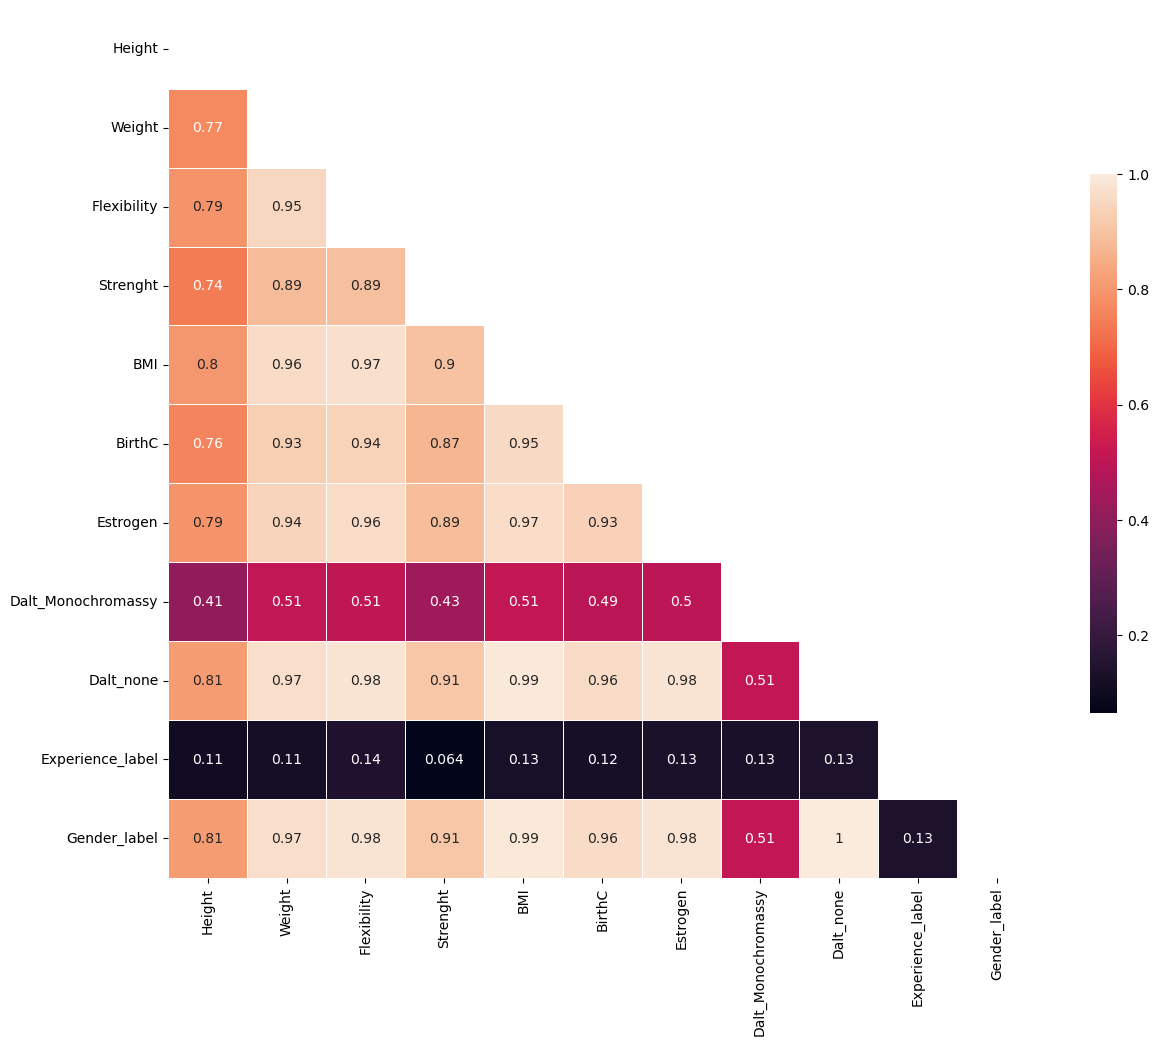

In [23]:
#A very common way to visualize the results discussed above is to create a correlation matrix.
# This is shown below.
# Only the lower triangular component of the matrix is shown due to the fact that
# the upper and lower (triangular) parts of the matrix are equal
import matplotlib.pyplot as plt
import seaborn as sn

corr=np.abs(X_train_normalized.corr())

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(14, 14))
# Generate a custom diverging colormap
cmap = sn.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sn.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

In [24]:
X_train_normalized.head()

,Height,Weight,Flexibility,Strenght,BMI,BirthC,Estrogen,Dalt_Monochromassy,Dalt_none,Experience_label,Gender_label
0,0.406855,0.081586,0.843418,0.444700,0.167735,1.0,0.885701,0.0,1.0,0.0,1.0
1,0.575998,0.833336,0.207595,0.841361,0.801393,0.0,0.180516,1.0,0.0,1.0,0.0
2,0.475237,0.246456,0.815950,0.153863,0.104821,1.0,0.802822,0.0,1.0,1.0,1.0
3,1.000000,0.977817,0.080974,0.678957,0.799207,0.0,0.165701,0.0,0.0,0.0,0.0
4,0.737510,0.859732,0.155775,0.739820,0.892765,0.0,0.174311,0.0,0.0,0.0,0.0


In [25]:
# very clear that all variables are essentially the same! Except for experience!
# what is the effect of this?

#let's get rid of such variables
X_train_reduced = X_train_normalized[['Gender_label','Experience_label']]
X_test_reduced = X_test_normalized[['Gender_label','Experience_label']]

In [26]:
# creating our knn model
knn = KNeighborsRegressor(n_neighbors=3)
# training the model on reduced, normalized data
knn.fit(X_train_reduced, y_train)
# testing algorithm on reduced, normalized test
pred = knn.predict(X_test_reduced)

np.sqrt(mean_squared_error(y_test,pred))

3110.50790418521

# Feature manipulation for signal boosting

In [27]:
# we want to understand what drives loss of energy in our windfarms
energy = pd.read_csv('energy_loss.csv')
energy.head()

,Loss,Voltage,Rotation,Stability
0,112.226170,105.691563,159.023456,89.002299
1,45.570772,102.941745,155.265519,92.429811
2,70.105341,104.989796,149.004972,95.212876
3,238.675027,97.525861,163.093562,98.138643
4,128.093533,110.614898,151.604033,93.717455


In [28]:
# let's try to predict it "raw"
X = energy[['Voltage','Rotation','Stability']]
y = energy['Loss']

In [29]:
import numpy as np
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X, y)
reg.score(X, y)

0.006501958809303154

In [30]:
# however we know the optimal values of Voltage, Rotation and Stability from an engineer
energy_transformed = energy.copy()
energy_transformed['Voltage'] = np.square(energy_transformed['Voltage']-100)
energy_transformed['Rotation'] = np.square(energy_transformed['Rotation']-150)
energy_transformed['Stability'] = np.square(energy_transformed['Stability']-90)
X = energy_transformed[['Voltage','Rotation','Stability']]
y = energy_transformed['Loss']

In [31]:
X

,Voltage,Rotation,Stability
0,32.393893,81.422749,0.995408
1,8.653864,27.725688,5.903980
2,24.898062,0.990081,27.174076
3,6.121364,171.441361,66.237512
4,112.676057,2.572923,13.819471
...,...,...,...
1995,152.536418,54.155420,4.860301
1996,31.849126,62.170431,14.066710
1997,69.889110,105.330374,44.976774
1998,134.995464,159.528113,61.857668


In [32]:
# the model improves dramatically
import numpy as np
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X, y)
reg.score(X, y)

0.9982401351758541